In [24]:
import numpy as np
import scanpy as sc
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_scipy_sparse_matrix

from vqniche.dataloaders.in_memory_dataset_blob import InMemoryDatasetBlob

In [26]:
adata = sc.read_h5ad('/lustre/scratch126/cellgen/team361/DATASETS/silver/sss2-1b_1p/sim1_1105fts_10000locs.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 10000 × 1105
    obs: 'cell_types', 'niche_types', 'cell_id'
    var: 'ensembl_id'
    uns: 'X_name', 'age_group', 'age_num', 'age_unit', 'assay', 'batch', 'citation', 'dataset_id', 'disease_level1', 'disease_level2', 'disease_level3', 'gp_data', 'log1p', 'sample', 'schema_reference', 'schema_version', 'sex', 'species', 'study', 'tissue', 'title'
    obsm: 'spatial'


In [27]:
data_directory_path = '/lustre/scratch126/cellgen/team361/DATASETS'
dataset_name = 'sss2-1b_1p' # xhs1000-39b_1p (Lloyd's skin dataset)
dataset_blob = InMemoryDatasetBlob(
                    name=dataset_name,
                    data_directory_path=data_directory_path,
                )

In [28]:
batch_id = 0
data_batch = dataset_blob[batch_id]
data_batch

Data(x_cell_gene_counts=[10000, 1105], y_cell_types=[10000, 8], y_niche_types=[10000, 8], edge_index_spatial_delaunay_radius_27.5=[2, 69944], edge_index_spatial_delaunay=[2, 69944], edge_index_spatial_n_neighs_4_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_7_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_10_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_12_radius_27.5=[2, 61308], edge_index_spatial_n_neighs_4=[2, 50000], edge_index_spatial_n_neighs_7=[2, 80000], edge_index_spatial_n_neighs_10=[2, 110000], edge_index_spatial_n_neighs_12=[2, 130000], cell_id=[10000, 1], dataset_id=[1, 1], tissue=[1, 1], species=[1, 1], batch=[1, 1])

In [29]:
graphs = {}
for key, value in data_batch.items():
    if key.startswith('edge_index_'):
        print(key)
        adj_sp = to_scipy_sparse_matrix(value)
        graphs[key] = nx.from_scipy_sparse_array(adj_sp)

edge_index_spatial_delaunay_radius_27.5
edge_index_spatial_delaunay
edge_index_spatial_n_neighs_4_radius_27.5
edge_index_spatial_n_neighs_7_radius_27.5
edge_index_spatial_n_neighs_10_radius_27.5
edge_index_spatial_n_neighs_12_radius_27.5
edge_index_spatial_n_neighs_4
edge_index_spatial_n_neighs_7
edge_index_spatial_n_neighs_10
edge_index_spatial_n_neighs_12


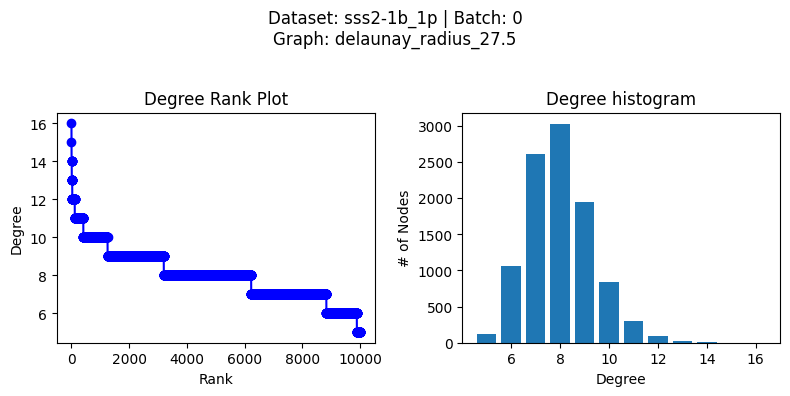

In [6]:
edge_index_name = 'edge_index_spatial_delaunay_radius_27.5'

G = graphs[edge_index_name]
degree_sequence = sorted((d for _, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(8, 4))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(axgrid[:, :2])
ax1.plot(degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.suptitle(f"Dataset: {dataset_name} | Batch: {batch_id}\nGraph: {edge_index_name[19:]}")

fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

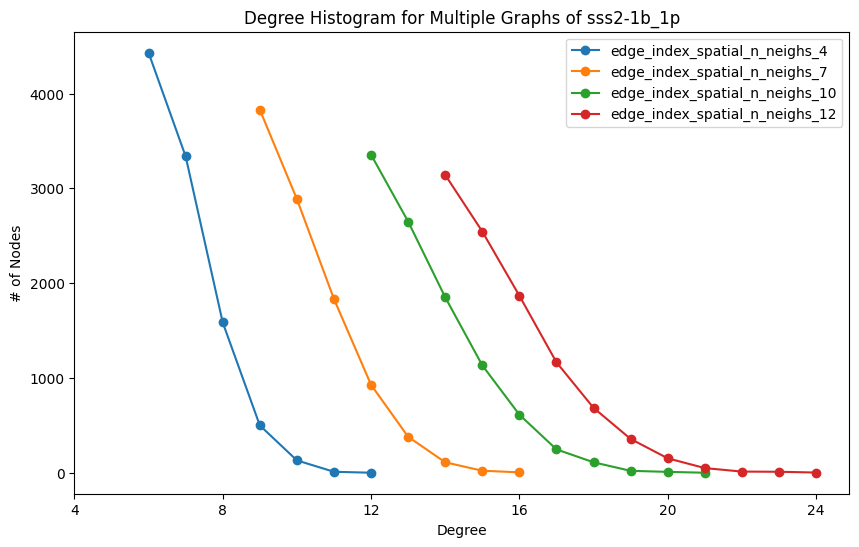

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

graph_keys = [
    'edge_index_spatial_n_neighs_4',
    'edge_index_spatial_n_neighs_7',
    'edge_index_spatial_n_neighs_10',
    'edge_index_spatial_n_neighs_12'
]

for key in graph_keys:
    G = graphs[key]
    degree_sequence = sorted((d for _, d in G.degree()), reverse=True)
    degrees, counts = np.unique(degree_sequence, return_counts=True)
    ax.plot(degrees, counts, marker='o', label=key)

ax.set_title("Degree Histogram for Multiple Graphs of sss2-1b_1p")
ax.set_xlabel("Degree")
ax.set_ylabel("# of Nodes")
ax.legend()
ax.set_xticks(np.arange(4, max(degrees) + 1, 4))

plt.show()